In [11]:
import xarray as xr
import numpy as np
from pathlib import Path

In [4]:
# parameters
FTLE_name_pattern = "010_FTLE_????-??-??.nc"
maxev_name_pattern = "010_max_eigenvalues_????-??-??.nc"

data_path = "."

In [5]:
FTLE_files = sorted(Path(data_path).glob(FTLE_name_pattern))
maxev_files = sorted(Path(data_path).glob(maxev_name_pattern))

In [12]:
maxev_ds = xr.concat(
    [
        # TODO: Let's set reftime in the 010 notebook already
        xr.open_dataset(fname).assign_coords(reftime=np.datetime64(fname.name[-13:-3]))
        for fname in maxev_files
    ],
    dim="reftime",
)
maxev_ds

<xarray.Dataset> Size: 20MB
Dimensions:      (reftime: 11, plon: 544, plat: 424)
Coordinates:
  * reftime      (reftime) datetime64[s] 88B 2025-08-12 ... 2025-08-22
  * plon         (plon) float64 4kB -29.0 -28.98 -28.97 ... -20.03 -20.02 -20.0
  * plat         (plat) float64 3kB 13.0 13.02 13.03 13.05 ... 19.97 19.98 20.0
Data variables:
    lambda_plus  (reftime, plon, plat) float64 20MB nan nan nan ... nan nan nan

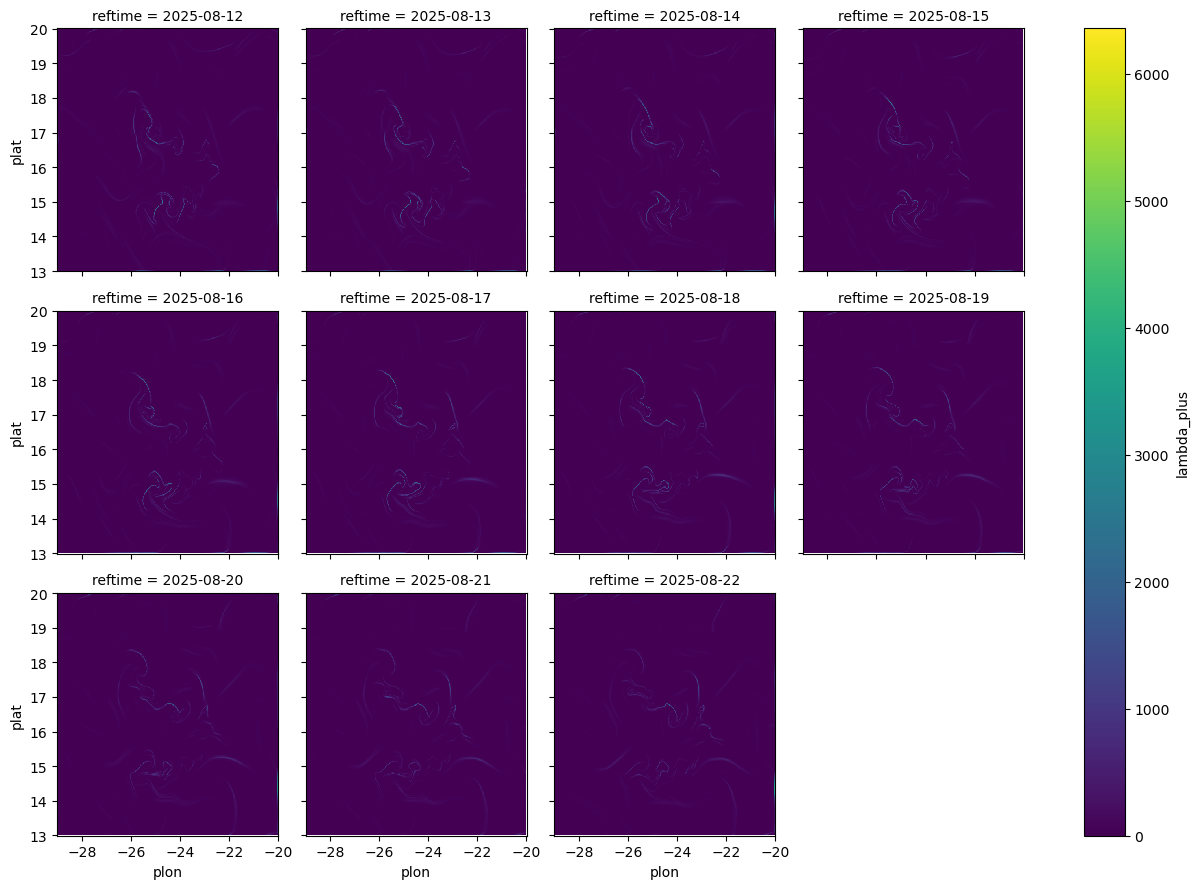

In [13]:
maxev_ds.lambda_plus.plot(x="plon", y="plat", col="reftime", col_wrap=4);

In [14]:
FTLE_ds = xr.concat(
    [
        xr.open_dataset(fname).assign_coords(reftime=np.datetime64(fname.name[-13:-3]))
        for fname in FTLE_files
    ],
    dim="reftime",
)
FTLE_ds

<xarray.Dataset> Size: 20MB
Dimensions:      (reftime: 11, plon: 544, plat: 424)
Coordinates:
  * reftime      (reftime) datetime64[s] 88B 2025-08-12 ... 2025-08-22
  * plon         (plon) float64 4kB -29.0 -28.98 -28.97 ... -20.03 -20.02 -20.0
  * plat         (plat) float64 3kB 13.0 13.02 13.03 13.05 ... 19.97 19.98 20.0
Data variables:
    lambda_plus  (reftime, plon, plat) float64 20MB nan nan nan ... nan nan nan

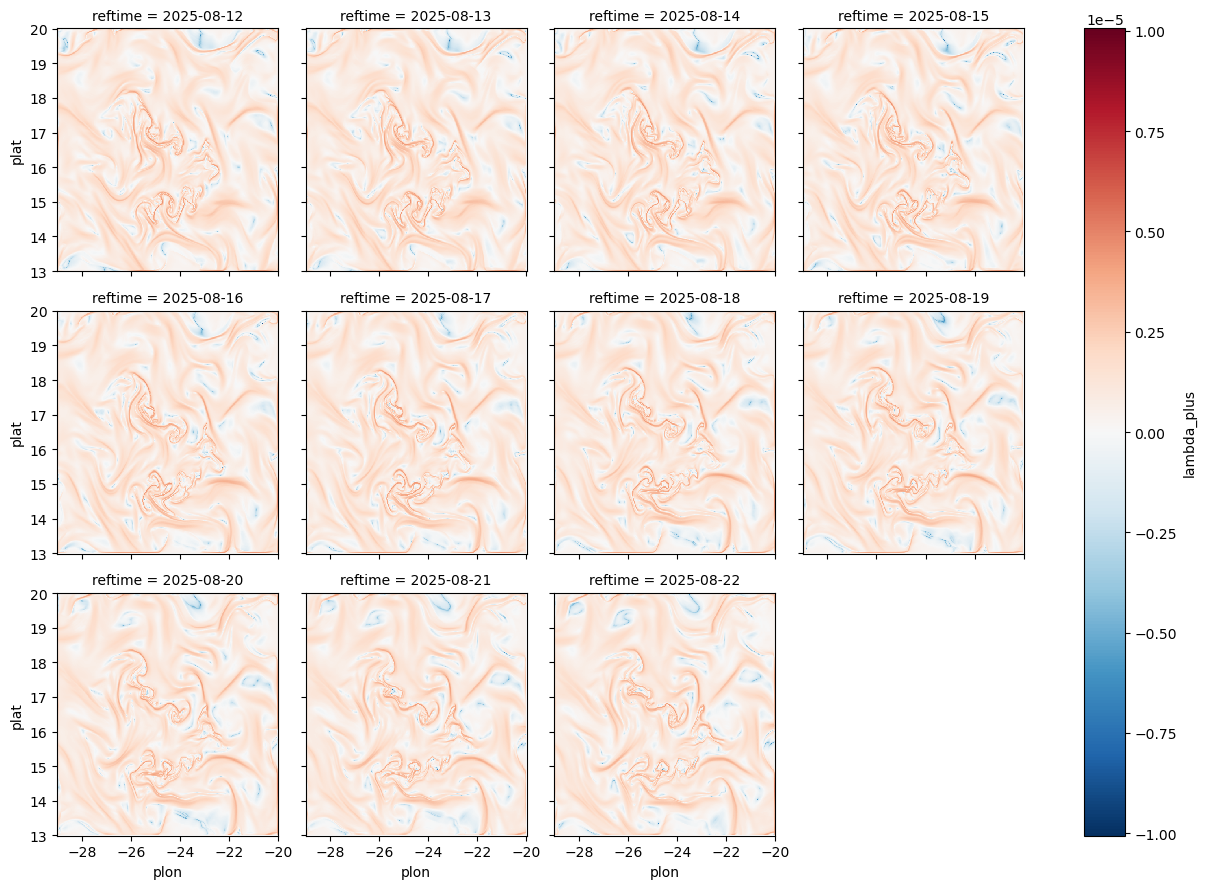

In [15]:
# TODO: plon and plat are not good names. Let's rename to lon and lat in 010 already
FTLE_ds.lambda_plus.plot(x="plon", y="plat", col="reftime", col_wrap=4);